# 01 — EDA: OULAD Load, Merge & Explore

Load core OULAD tables, define the **at-risk** target (`Withdrawn` or `Fail`), merge assessment and VLE engagement features, run basic EDA, and save a merged table to `data/processed/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# Resolve paths whether the notebook runs from notebooks/ or project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:     {RAW}")

Project root: d:\ed_project
Raw data:     d:\ed_project\data\raw


## 1. Load core tables

In [2]:
student_info = pd.read_csv(RAW / "studentInfo.csv")
student_assessment = pd.read_csv(RAW / "studentAssessment.csv")
assessments = pd.read_csv(RAW / "assessments.csv")
student_vle = pd.read_csv(RAW / "studentVle.csv")
vle = pd.read_csv(RAW / "vle.csv")

tables = {
    "student_info": student_info,
    "student_assessment": student_assessment,
    "assessments": assessments,
    "student_vle": student_vle,
    "vle": vle,
}

for name, df in tables.items():
    print(f"{name:22s} {df.shape[0]:>10,} rows × {df.shape[1]} cols")

student_info               32,593 rows × 12 cols
student_assessment        173,912 rows × 5 cols
assessments                   206 rows × 6 cols
student_vle            10,655,280 rows × 6 cols
vle                         6,364 rows × 6 cols


In [3]:
# Quick peek at each table
display(student_info.head(3))
display(student_assessment.head(3))
display(assessments.head(3))
display(student_vle.head(3))
display(vle.head(3))

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN


In [4]:
# Missing values (% of rows)
for name, df in tables.items():
    missing = df.isna().mean().sort_values(ascending=False)
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name}: no missing values")
    else:
        print(f"\n{name}:")
        print((missing * 100).round(2).to_string())


student_info:
imd_band    3.41

student_assessment:
score    0.1

assessments:
date    5.34
student_vle: no missing values

vle:
week_from    82.39
week_to      82.39


## 2. Define target variable

**At-risk** = student withdrew or failed the module presentation.

In [5]:
print("Final result distribution:")
print(student_info["final_result"].value_counts())
print()

student_info["at_risk"] = student_info["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

print(f"At-risk rate: {student_info['at_risk'].mean():.1%}")
student_info["at_risk"].value_counts()

Final result distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

At-risk rate: 52.8%


at_risk
1    17208
0    15385
Name: count, dtype: int64

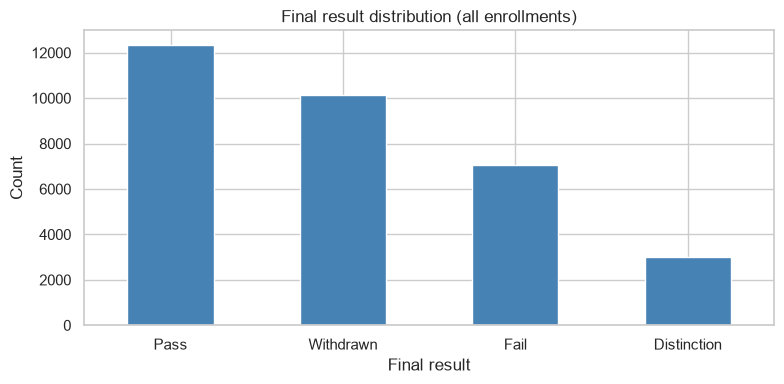

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
student_info["final_result"].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Final result distribution (all enrollments)")
ax.set_xlabel("Final result")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Feature aggregation

Join assessments for scores and lateness, then aggregate VLE click logs per student-module.

In [7]:
# Assessment scores + late submissions (date_submitted > due date)
sa = student_assessment.merge(assessments, on="id_assessment", how="inner")
sa["late"] = (sa["date_submitted"] > sa["date"]).astype(int)

assess_agg = (
    sa.groupby(["code_module", "code_presentation", "id_student"], as_index=False)
    .agg(
        mean_score=("score", "mean"),
        n_assessments=("score", "count"),
        late_submission_count=("late", "sum"),
        avg_days_to_submit=("date_submitted", "mean"),
    )
)

print(f"Assessment aggregates: {assess_agg.shape}")
assess_agg.head()

Assessment aggregates: (25843, 7)


,code_module,code_presentation,id_student,mean_score,n_assessments,late_submission_count,avg_days_to_submit
0,AAA,2013J,11391,82.0,5,0,112.4
1,AAA,2013J,28400,66.4,5,2,114.2
2,AAA,2013J,31604,76.0,5,0,112.2
3,AAA,2013J,32885,54.4,5,5,125.6
4,AAA,2013J,38053,68.0,5,1,116.2


In [8]:
# VLE engagement: total clicks and active days per student-module
vle_agg = (
    student_vle.groupby(["code_module", "code_presentation", "id_student"], as_index=False)
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        first_activity_day=("date", "min"),
        last_activity_day=("date", "max"),
    )
)

print(f"VLE aggregates: {vle_agg.shape}")
vle_agg.head()

VLE aggregates: (29228, 7)


,code_module,code_presentation,id_student,total_clicks,active_days,first_activity_day,last_activity_day
0,AAA,2013J,11391,934,40,-5,253
1,AAA,2013J,28400,1435,80,-10,239
2,AAA,2013J,30268,281,12,-10,12
3,AAA,2013J,31604,2158,123,-10,264
4,AAA,2013J,32885,1034,70,-10,247


## 4. Merge into one table

In [9]:
keys = ["code_module", "code_presentation", "id_student"]

df = (
    student_info
    .merge(assess_agg, on=keys, how="left")
    .merge(vle_agg, on=keys, how="left")
)

# Students with no VLE/assessment rows get NaN — fill counts with 0
count_cols = ["n_assessments", "late_submission_count", "total_clicks", "active_days"]
df[count_cols] = df[count_cols].fillna(0)

print(f"Merged shape: {df.shape}")
print(f"At-risk rate: {df['at_risk'].mean():.1%}")
df.head()

Merged shape: (32593, 21)
At-risk rate: 52.8%


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,at_risk,mean_score,n_assessments,late_submission_count,avg_days_to_submit,total_clicks,active_days,first_activity_day,last_activity_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,Pass,0,82.0,5.0,0.0,112.4,934.0,40.0,-5.0,253.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,Pass,0,66.4,5.0,2.0,114.2,1435.0,80.0,-10.0,239.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,Withdrawn,1,NaN,0.0,0.0,NaN,281.0,12.0,-10.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,Pass,0,76.0,5.0,0.0,112.2,2158.0,123.0,-10.0,264.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,Pass,0,54.4,5.0,5.0,125.6,1034.0,70.0,-10.0,247.0


## 5. Exploratory analysis

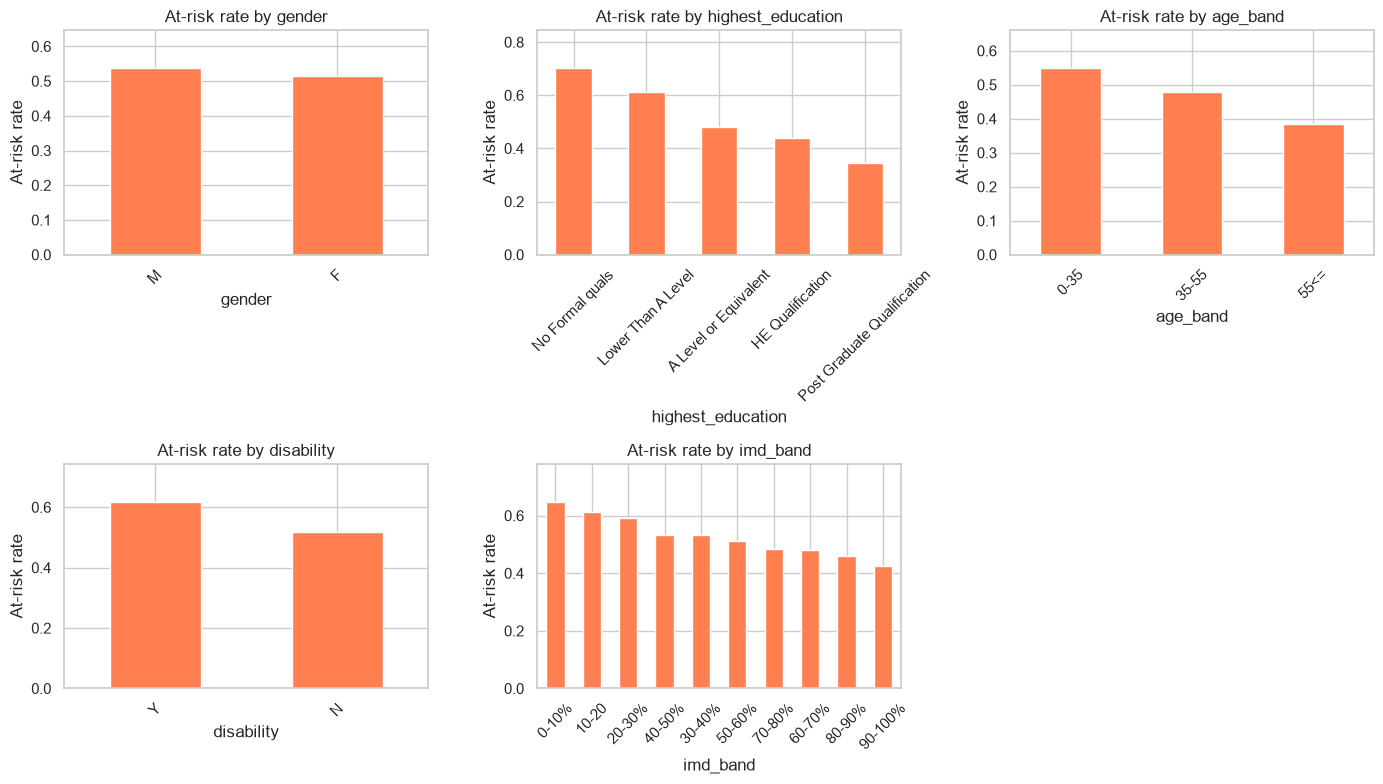

In [10]:
# At-risk rate by demographic slices
demo_cols = ["gender", "highest_education", "age_band", "disability", "imd_band"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, demo_cols):
    rates = df.groupby(col)["at_risk"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
    ax.set_title(f"At-risk rate by {col}")
    ax.set_ylabel("At-risk rate")
    ax.set_ylim(0, rates.max() * 1.2)
    ax.tick_params(axis="x", rotation=45)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [11]:
df["mean_score"].isna().mean()      # students with no assessment scores
df["total_clicks"].eq(0).mean()     # students with zero VLE activity
df.shape[0], student_info.shape[0]  # should match (one row per enrollment)

(32593, 32593)

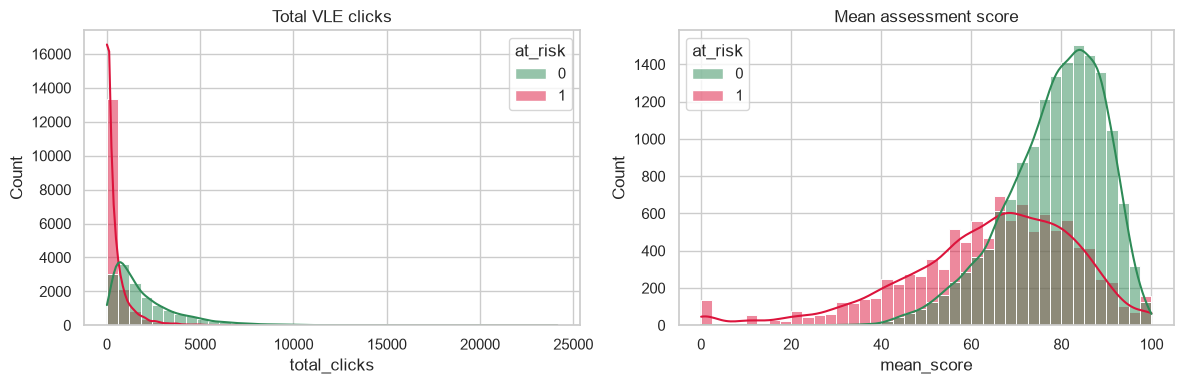

In [12]:
# Engagement vs outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ["total_clicks", "mean_score"],
    ["Total VLE clicks", "Mean assessment score"],
):
    sns.histplot(
        data=df,
        x=col,
        hue="at_risk",
        bins=40,
        kde=True,
        ax=ax,
        palette={0: "seagreen", 1: "crimson"},
        common_norm=False,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

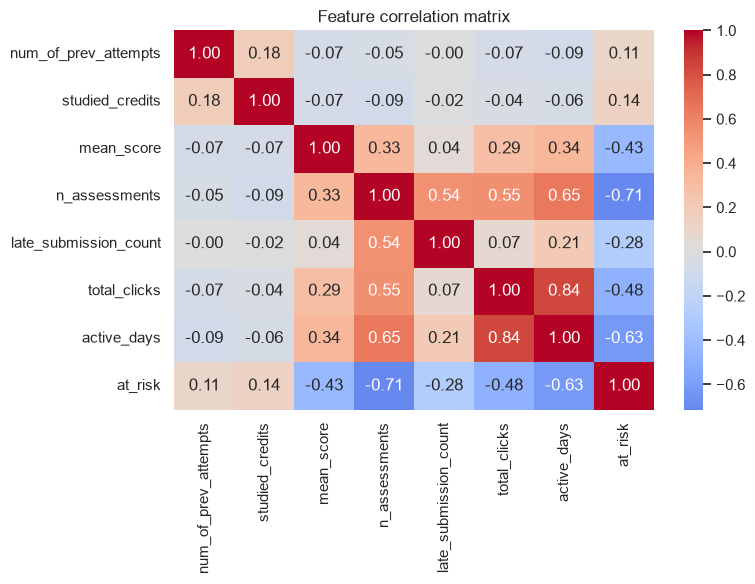

In [13]:
# Numeric feature correlation with at_risk
numeric_cols = [
    "num_of_prev_attempts",
    "studied_credits",
    "mean_score",
    "n_assessments",
    "late_submission_count",
    "total_clicks",
    "active_days",
    "at_risk",
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [14]:
# Summary stats split by at_risk
summary_cols = ["mean_score", "late_submission_count", "total_clicks", "active_days"]
df.groupby("at_risk")[summary_cols].agg(["mean", "median", "std"]).round(2)

mean_score              late_submission_count               \
              mean median   std                  mean median   std   
at_risk                                                              
0            78.60  80.27  11.0                  2.17    1.0  2.51   
1            64.17  66.85  19.0                  0.93    0.0  1.67   

        total_clicks                  active_days                
                mean  median      std        mean median    std  
at_risk                                                          
0            2068.23  1425.0  1996.76       91.56   82.0  53.29  
1             452.43   175.0   793.32       23.21   12.0  29.74

## 6. Save merged table

Output feeds `02_feature_engineering.ipynb` (early-window features) and later modeling notebooks.

In [15]:
out_path = PROCESSED / "student_merged.csv"
df.to_csv(out_path, index=False)

print(f"Saved {df.shape[0]:,} rows × {df.shape[1]} cols → {out_path}")

Saved 32,593 rows × 21 cols → d:\ed_project\data\processed\student_merged.csv
